Time Warping is The time axis itself is distorted by generating a smooth warp path via cubic spline over knots sampled from 𝒩(1, σ²), then resampling the series along the warped timeline. This differs from magnitude warping in that it compresses/stretches temporal structure, not amplitude.

In [1]:
import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline
import matplotlib.pyplot as plt


## loading data

In [2]:
fd001=pd.read_csv('/mnt/c/Users/PC/Downloads/AI/DeepLearning/Data PreProcessing/CLEANED_DATA/train/train_FD001_cleaned.csv',sep=',')
fd001_arr=fd001.to_numpy()
print(fd001_arr.shape)


(20631, 20)


In [3]:
fd002=pd.read_csv('/mnt/c/Users/PC/Downloads/AI/DeepLearning/Data PreProcessing/CLEANED_DATA/train/train_FD002_cleaned.csv',sep=',')
fd002_arr=fd002.to_numpy()
print(fd002_arr.shape)


(53759, 20)


In [4]:
fd003=pd.read_csv('/mnt/c/Users/PC/Downloads/AI/DeepLearning/Data PreProcessing/CLEANED_DATA/train/train_FD003_cleaned.csv',sep=',')
fd003_arr=fd003.to_numpy()
print(fd003_arr.shape)

(24720, 20)


In [5]:
fd004=pd.read_csv('/mnt/c/Users/PC/Downloads/AI/DeepLearning/Data PreProcessing/CLEANED_DATA/train/train_FD004_cleaned.csv',sep=',')
fd004_arr=fd004.to_numpy()
print(fd004_arr.shape)

(61249, 20)


## plotting the time warping method

In [6]:
#define number of knots
n_knots=4
seq_len = fd001_arr.shape[0]
# Generate warp factors at knots (around 1)
knots = np.linspace(0, seq_len-1, n_knots).astype(int)
knot_factors = np.random.normal(loc=1.0, scale=0.2, size=n_knots)
print(knots)
print(knot_factors) 

[    0  6876 13753 20630]
[0.50962735 0.93535412 1.21981805 0.84457447]


In [7]:
# Cubic spline to get smooth warping function
cs = CubicSpline(knots, knot_factors, bc_type='natural')
warp = cs(np.arange(seq_len))   # shape (seq_len,)
# Compute cumulative sum of warp to get new time indices
cum_warp = np.cumsum(warp)
# Normalize to original range [0, seq_len-1]
cum_warp = (cum_warp - cum_warp.min()) / (cum_warp.max() - cum_warp.min()) * (seq_len - 1)

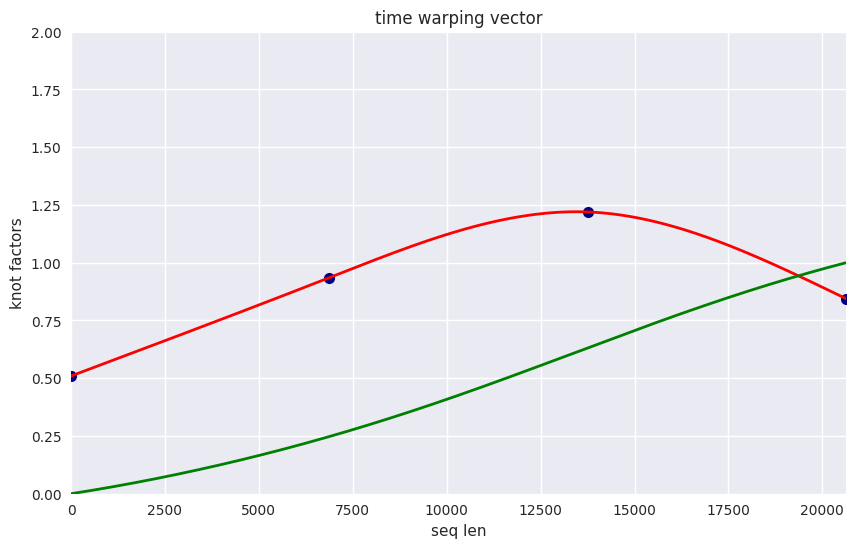

In [8]:
plt.style.use("seaborn-v0_8")
fig , ax = plt.subplots(figsize=(10,6))
ax.set_xlabel('seq len')
ax.set_ylabel('knot factors')
ax.set_title('time warping vector')
plt.xlim(0,seq_len)
plt.ylim(0,2)
ax.plot(knots, knot_factors, 'o', label="knots", color="navy", markersize=8)
ax.plot(np.arange(seq_len), warp, label="spline factors", color="red", linewidth=2)
ax.plot(np.arange(seq_len), cum_warp/seq_len, label="normalized cumulative warp", color="green", linewidth=2)

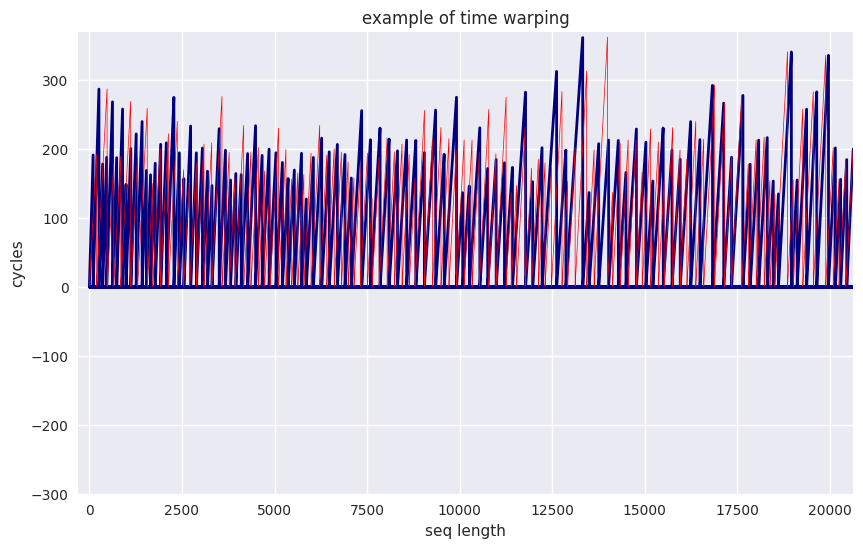

In [ ]:
# Interpolate original signal at new indices
X=fd001_arr
new_X = np.zeros_like(X)
new_X[:, 1] = np.interp(np.arange(seq_len), cum_warp, X[:, 1])
fig , ax = plt.subplots(figsize=(10,6))
ax.set_xlabel('seq length')
ax.set_ylabel('cycles')
ax.set_title('example of time warping')
warped_len=np.arange(seq_len)
plt.xlim(-300,len(warped_len))#ensuring no negative cycles values 
plt.ylim(-300,370)#ensuring no negative cycles values
ax.plot(warped_len,new_X,label='new warped cycles',color='navy',linewidth=2)
ax.plot(warped_len,fd001_arr[:,1],label='cycles',color='red',linewidth=0.5)

In [10]:
def time_warping(X, n_knots=4, sigma=0.2):
    """
    X : (seq_len, n_features)
    returns time-warped version (same length)
    """
    seq_len = X.shape[0]
    # Generate warp factors at knots (around 1)
    knots = np.linspace(0, seq_len-1, n_knots).astype(int)
    knot_factors = np.random.normal(loc=1.0, scale=sigma, size=n_knots)
    # Cubic spline to get smooth warping function
    cs = CubicSpline(knots, knot_factors, bc_type='natural')
    warp = cs(np.arange(seq_len))   # shape (seq_len,)
    # Compute cumulative sum of warp to get new time indices
    cum_warp = np.cumsum(warp)
    # Normalize to original range [0, seq_len-1]
    cum_warp = (cum_warp - cum_warp.min()) / (cum_warp.max() - cum_warp.min()) * (seq_len - 1)
    # Interpolate original signal at new indices
    new_X = np.zeros_like(X)
    for f in range(X.shape[1]):
        new_X[:, f] = np.interp(np.arange(seq_len), cum_warp, X[:, f])
    return new_X

In [11]:
fd001_cols=fd001.columns
fd002_cols=fd002.columns
fd003_cols=fd003.columns
fd004_cols=fd004.columns

In [12]:
scaled_fd001=time_warping(fd001_arr)
print(scaled_fd001)
scaled_fd001_df=pd.DataFrame(scaled_fd001,columns=fd001_cols)
scaled_fd001_df.to_csv('time_warping_fd001.csv')

[[  1.           1.         191.         ... 392.          39.06
   23.419     ]
 [  1.           1.79357556 190.20642444 ... 392.          39.01238547
   23.42265045]
 [  1.           2.58717765 189.41282235 ... 390.82564469  38.97064112
   23.37697809]
 ...
 [100.         197.07770952   2.92229048 ... 395.23312856  38.31087933
   23.14182988]
 [100.         198.53875623   1.46124377 ... 396.38373132  38.35918657
   23.00371544]
 [100.         200.           0.         ... 396.          38.37
   23.0522    ]]


In [13]:
print(fd002_arr)

[[  1.       1.     148.     ... 334.      14.73     8.8071]
 [  1.       2.     147.     ... 330.      10.41     6.2665]
 [  1.       3.     146.     ... 309.      14.08     8.6723]
 ...
 [260.     314.       2.     ... 310.      14.19     8.5503]
 [260.     315.       1.     ... 311.      14.05     8.3729]
 [260.     316.       0.     ... 338.      14.75     8.8446]]


In [15]:
scaled_fd002=time_warping(fd002_arr)
print(scaled_fd002)
scaled_fd002_df=pd.DataFrame(scaled_fd002,columns=fd002_cols)
scaled_fd002_df.to_csv('time_warping_fd002.csv')

[[  1.           1.         148.         ... 334.          14.73
    8.8071    ]
 [  1.           1.7243699  147.2756301  ... 331.10252038  11.60072201
    6.96676582]
 [  1.           2.44875085 146.55124915 ... 320.57623216  12.05691562
    7.34610479]
 ...
 [260.         313.63768439   2.36231561 ... 333.18819875  19.22981007
   11.59197574]
 [260.         314.81883156   1.18116844 ... 310.81883156  14.07536358
    8.40503928]
 [260.         316.           0.         ... 338.          14.75
    8.8446    ]]


In [16]:
scaled_fd003=time_warping(fd003_arr)
print(scaled_fd003)
scaled_fd003_df=pd.DataFrame(scaled_fd003,columns=fd003_cols)
scaled_fd003_df.to_csv('time_warping_fd003.csv')

[[  1.           1.         258.         ... 391.          39.11
   23.3537    ]
 [  1.           2.2799071  256.7200929  ... 391.7200929   38.95081301
   23.42609164]
 [  1.           3.55984846 255.44015154 ... 391.55984846  38.91158333
   23.32670288]
 ...
 [100.         150.36720721   1.63279279 ... 395.63279279  38.36062342
   23.07080717]
 [100.         151.1835995    0.8164005  ... 395.1835995   38.35589987
   23.07702584]
 [100.         152.           0.         ... 396.          38.56
   23.0847    ]]


In [17]:
scaled_fd004=time_warping(fd004_arr)
print(scaled_fd004)
scaled_fd004_df=pd.DataFrame(scaled_fd004,columns=fd004_cols)
scaled_fd004_df.to_csv('time_warping_fd004.csv')

[[  1.           1.         320.         ... 330.          10.62
    6.367     ]
 [  1.           2.03301392 318.96698608 ... 359.94355454  23.91143664
   14.38336668]
 [  1.           3.06604209 317.93395791 ... 328.93395791  10.48396253
    6.42105564]
 ...
 [249.         253.01366001   1.98633999 ... 394.20771949  39.44505658
   23.62552033]
 [249.         254.00682268   0.99317732 ... 336.97270928  15.22861567
    9.05936561]
 [249.         255.           0.         ... 333.          10.66
    6.4341    ]]
